# ResNet Ablation Study — Residual Connection의 효과 검증

## 프로젝트 목적
ResNet의 핵심인 **residual connection(skip connection)** 을 직접 구현하고,
동일한 깊이의 **PlainNet(skip 제거)** 과 비교하여 그 효과를 확인한다.

## 비교 모델 (4개)
| 모델 | 블록 | Stage | Skip |
|---|---|---|---|
| ResNet-34 / Plain-34 | BasicBlock | [3,4,6,3] | O / X |
| ResNet-50 / Plain-50 | Bottleneck | [3,4,6,3] | O / X |

## 데이터 분할
- **train / val / test** 3분할로 진행한다.
- 학습 중 성능 비교는 **validation** 으로 하고(= Ablation 결과표 기준),
  최종 일반화 성능은 학습이 끝난 뒤 **test** 로 딱 한 번 확인한다.

## 가설
같은 깊이·같은 학습 조건에서 **skip을 켠 ResNet이 Plain보다 더 안정적으로
학습되고 validation accuracy가 높을 것**이다. skip 유무만 다르므로
성능 차이는 곧 residual connection의 효과로 해석할 수 있다.

## 0. 실행 환경 / 재현성

In [8]:
# 실행 환경 확인
import torch
print('GPU:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('이름:', torch.cuda.get_device_name(0))

GPU: True
이름: Tesla T4


In [9]:
# 재현성 시드 고정 (초기 가중치 / 셔플 / 데이터 분할의 무작위성을 잡는다)
import random, numpy as np

SEED = 42

def set_seed(seed: int = SEED) -> None:
    """난수 생성기를 모두 고정해 실험을 재현 가능하게 만든다."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)
print('seed 고정 완료:', SEED)

seed 고정 완료: 42


## 1. 데이터 준비 (Oxford-IIIT Pet, 37클래스)

In [10]:
# HuggingFace datasets로 반려동물 37종 분류 데이터셋 로드
!pip install -q datasets
from datasets import load_dataset

pet = load_dataset("timm/oxford-iiit-pet")   # {'train', 'test'}
print(pet)

DatasetDict({
    train: Dataset({
        features: ['image', 'label', 'image_id', 'label_cat_dog'],
        num_rows: 3680
    })
    test: Dataset({
        features: ['image', 'label', 'image_id', 'label_cat_dog'],
        num_rows: 3669
    })
})


In [11]:
# 클래스 수 확인 → 분류기 출력 차원(37)이 여기서 정해진다.
import torchvision.transforms as T
from torch.utils.data import Dataset, DataLoader

print(pet['train'].features)
print('클래스 수:', len(pet['train'].features['label'].names))

{'image': Image(mode=None, decode=True), 'label': ClassLabel(names=['abyssinian', 'american_bulldog', 'american_pit_bull_terrier', 'basset_hound', 'beagle', 'bengal', 'birman', 'bombay', 'boxer', 'british_shorthair', 'chihuahua', 'egyptian_mau', 'english_cocker_spaniel', 'english_setter', 'german_shorthaired', 'great_pyrenees', 'havanese', 'japanese_chin', 'keeshond', 'leonberger', 'maine_coon', 'miniature_pinscher', 'newfoundland', 'persian', 'pomeranian', 'pug', 'ragdoll', 'russian_blue', 'saint_bernard', 'samoyed', 'scottish_terrier', 'shiba_inu', 'siamese', 'sphynx', 'staffordshire_bull_terrier', 'wheaten_terrier', 'yorkshire_terrier']), 'image_id': Value('string'), 'label_cat_dog': ClassLabel(names=['cat', 'dog'])}
클래스 수: 37


In [12]:
# 전처리 정의 + HF 데이터를 PyTorch Dataset으로 감싸는 래퍼
MEAN = (0.485, 0.456, 0.406)   # ImageNet 표준값
STD  = (0.229, 0.224, 0.225)

train_tf = T.Compose([
    T.Resize((224, 224)),
    T.RandomHorizontalFlip(),   # 학습셋에만 증강 적용
    T.ToTensor(),
    T.Normalize(MEAN, STD),
])
eval_tf = T.Compose([           # val·test 공용: 무작위 증강 없이 크기/정규화만
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(MEAN, STD),
])

class PetHF(Dataset):
    """HuggingFace pet 데이터셋을 PyTorch DataLoader용으로 감싼 래퍼.

    indices 인자를 주면 해당 스플릿의 부분집합만 사용한다.
    → HF의 'train' 스플릿 하나를 train/val 두 개로 쪼갤 때 사용한다.
    흑백(1채널) 이미지는 RGB(3채널)로 변환해 채널을 통일한다.

    Args:
        split (str): 'train' 또는 'test'
        transform: 적용할 torchvision 전처리
        indices (list[int] | None): 사용할 원본 인덱스. None이면 전체.
    """
    def __init__(self, split, transform=None, indices=None):
        self.ds = pet[split]
        self.transform = transform
        self.classes = self.ds.features['label'].names
        self.indices = list(range(len(self.ds))) if indices is None else list(indices)

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, i):
        idx = int(self.indices[i])              # 부분집합 위치 → 원본 인덱스
        item = self.ds[idx]
        img, label = item['image'], item['label']
        if img.mode != 'RGB':              # 흑백 이미지 방어 처리
            img = img.convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, label

### 1-1. train / val / test 3분할 (층화 분할)

HF가 주는 `train` 스플릿을 **train / validation 으로 층화 분할(80/20)** 하고,
`test` 스플릿은 최종 평가용으로 그대로 보존한다.
- **층화(stratified):** 37개 품종이 train과 val에 같은 비율로 들어가게 맞춘다.
  (안 하면 특정 품종이 한쪽에 쏠릴 수 있다.)
- **val:** 학습 중 성능 비교·Ablation 기준.
- **test:** 학습이 다 끝난 뒤 최종 성능만 한 번 측정.

In [13]:
VAL_RATIO = 0.2
labels_all = np.array(pet['train']['label'])   # train 스플릿의 라벨 전체

rng = np.random.default_rng(SEED)               # 분할 재현을 위해 시드 고정
val_idx, train_idx = [], []
for c in np.unique(labels_all):                 # 클래스별로 나눠 담기 = 층화
    idx_c = np.where(labels_all == c)[0]
    rng.shuffle(idx_c)
    n_val = int(len(idx_c) * VAL_RATIO)
    val_idx.extend(idx_c[:n_val])
    train_idx.extend(idx_c[n_val:])

ds_train = PetHF('train', train_tf, indices=train_idx)  # 학습 (증강 O)
ds_val   = PetHF('train', eval_tf,  indices=val_idx)    # 검증 (train에서 분리, 증강 X)
ds_test  = PetHF('test',  eval_tf)                      # 최종 평가 (증강 X)

print(f'train {len(ds_train)} | val {len(ds_val)} | test {len(ds_test)}')
print('train∩val 겹침:', len(set(train_idx) & set(val_idx)))   # 0이어야 정상
# 층화 확인: train/val 클래스 분포 비율이 비슷해야 한다
from collections import Counter
tr_c = Counter(np.array(pet['train']['label'])[train_idx])
va_c = Counter(np.array(pet['train']['label'])[val_idx])
print('예시 클래스 0~2 (train/val):',
      [(int(k), tr_c[k], va_c[k]) for k in [0, 1, 2]])

train 2946 | val 734 | test 3669
train∩val 겹침: 0
예시 클래스 0~2 (train/val): [(0, 80, 20), (1, 80, 20), (2, 80, 20)]


In [14]:
# sanity check: 한 장 꺼내 shape/값범위 확인
img, label = ds_train[0]
print('이미지 shape:', img.shape)                    # [3, 224, 224]
print('값 범위: %.2f ~ %.2f' % (img.min(), img.max()))
print('클래스 수:', len(ds_train.classes))

이미지 shape: torch.Size([3, 224, 224])
값 범위: -1.95 ~ 2.41
클래스 수: 37


In [15]:
# DataLoader 3종 생성 (val/test는 shuffle=False)
BATCH_SIZE = 32

g = torch.Generator(); g.manual_seed(SEED)
def seed_worker(worker_id):
    ws = torch.initial_seed() % 2**32
    np.random.seed(ws); random.seed(ws)

train_loader = DataLoader(ds_train, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True,
                          worker_init_fn=seed_worker, generator=g)
val_loader   = DataLoader(ds_val,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)
test_loader  = DataLoader(ds_test,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)

imgs, labels = next(iter(train_loader))
print(imgs.shape)   # [32, 3, 224, 224]

torch.Size([32, 3, 224, 224])


## 2. 모델 설계 — ★ 핵심 ★

아래 `BasicBlock`·`Bottleneck`·`ResNet` 이 프로젝트의 **가장 핵심적이고 복잡한 부분**이다.
residual connection을 직접 구현하는 곳이자, `use_skip` 플래그 **한 줄**로 ResNet과
PlainNet을 모두 만들어 ablation을 가능하게 하는 설계이기 때문이다.

In [16]:
import torch.nn as nn
import torch.nn.functional as F

class BasicBlock(nn.Module):
    """ResNet-34용 기본 블록. (프로젝트 핵심 1/2)

    구조:  x ─▶ [3x3 Conv-BN-ReLU ▶ 3x3 Conv-BN] = F(x)
                 └────────── shortcut(x) ──────────┘  (+) ▶ ReLU

    작동 원리 & 존재 이유:
      메인 경로 F(x)의 출력에 입력 x(shortcut)를 **더하는 것**이 residual
      connection이다. 네트워크가 '변화량 F'만 학습하면 되어 깊은 망에서도
      기울기가 잘 흘러 학습이 안정적이다.

    use_skip 플래그(핵심):
      - True  → out = F(x) + shortcut(x)   → ResNet
      - False → out = F(x)                 → PlainNet
      동일 구조에서 이 한 줄만 꺼서 residual의 효과를 분리 측정한다.

    Args:
        in_ch, out_ch (int): 입력/출력 채널
        stride (int): 2이면 공간 크기를 절반으로 축소
        use_skip (bool): 잔차 연결 사용 여부
    """
    expansion = 1

    def __init__(self, in_ch, out_ch, stride=1, use_skip=True):
        super().__init__()
        self.use_skip = use_skip
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, stride=stride, padding=1, bias=False)
        self.bn1   = nn.BatchNorm2d(out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, stride=1, padding=1, bias=False)
        self.bn2   = nn.BatchNorm2d(out_ch)
        self.shortcut = nn.Sequential()
        if stride != 1 or in_ch != out_ch:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 1, stride=stride, bias=False),
                nn.BatchNorm2d(out_ch),
            )

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        if self.use_skip:                 # ← ResNet vs Plain을 가르는 한 줄
            out = out + self.shortcut(x)
        return F.relu(out)

In [17]:
class Bottleneck(nn.Module):
    """ResNet-50용 블록. (프로젝트 핵심 2/2)

    구조: 1x1(채널 축소) ▶ 3x3(공간 처리) ▶ 1x1(채널 4배 확대) + shortcut.
    존재 이유: 깊은 망에서 3x3 연산을 저채널 구간에 몰아 연산량을 아낀다.
    BasicBlock과 동일하게 use_skip으로 잔차 연결을 켜고 끈다.

    Args:
        in_ch (int): 입력 채널
        mid_ch (int): 3x3의 채널(출력 = mid_ch * expansion)
        stride (int): 2이면 다운샘플
        use_skip (bool): 잔차 연결 사용 여부
    """
    expansion = 4

    def __init__(self, in_ch, mid_ch, stride=1, use_skip=True):
        super().__init__()
        self.use_skip = use_skip
        out_ch = mid_ch * self.expansion
        self.conv1 = nn.Conv2d(in_ch, mid_ch, 1, bias=False)
        self.bn1   = nn.BatchNorm2d(mid_ch)
        self.conv2 = nn.Conv2d(mid_ch, mid_ch, 3, stride=stride, padding=1, bias=False)
        self.bn2   = nn.BatchNorm2d(mid_ch)
        self.conv3 = nn.Conv2d(mid_ch, out_ch, 1, bias=False)
        self.bn3   = nn.BatchNorm2d(out_ch)
        self.shortcut = nn.Sequential()
        if stride != 1 or in_ch != out_ch:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 1, stride=stride, bias=False),
                nn.BatchNorm2d(out_ch),
            )

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = F.relu(self.bn2(self.conv2(out)))
        out = self.bn3(self.conv3(out))
        if self.use_skip:
            out = out + self.shortcut(x)
        return F.relu(out)

In [18]:
# 블록 단위 shape 검증
b1 = BasicBlock(64, 64, stride=1)
x = torch.randn(1, 64, 56, 56)
print('BasicBlock 유지 :', tuple(b1(x).shape))    # (1, 64, 56, 56)
b2 = BasicBlock(64, 128, stride=2)
print('BasicBlock 다운 :', tuple(b2(x).shape))    # (1, 128, 28, 28)
b3 = Bottleneck(64, 64, stride=1)
print('Bottleneck     :', tuple(b3(x).shape))     # (1, 256, 56, 56)

BasicBlock 유지 : (1, 64, 56, 56)
BasicBlock 다운 : (1, 128, 28, 28)
Bottleneck     : (1, 256, 56, 56)


In [19]:
class ResNet(nn.Module):
    """Stem + 4 Stage + 분류부로 이루어진 ResNet 본체.

    1) Stem(7x7 conv + maxpool)으로 224→56 축소.
    2) 4개 스테이지에서 블록을 [3,4,6,3]번 쌓으며 채널↑·크기↓.
       각 스테이지 첫 블록만 stride=2로 다운샘플, 나머지는 크기 유지.
    3) 전역 평균 풀링 → Linear로 num_classes(37) 분류.
    use_skip을 모든 블록에 전달해 모델 전체를 ResNet/Plain으로 전환한다.

    Args:
        block: BasicBlock 또는 Bottleneck
        num_blocks (list[int]): 스테이지별 블록 수 [3,4,6,3]
        num_classes (int): 출력 클래스 수
        use_skip (bool): 잔차 연결 사용 여부
    """
    def __init__(self, block, num_blocks, num_classes=37, use_skip=True):
        super().__init__()
        self.in_ch = 64
        self.stem = nn.Sequential(
            nn.Conv2d(3, 64, 7, stride=2, padding=3, bias=False),
            nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.MaxPool2d(3, stride=2, padding=1),
        )
        self.layer1 = self._make_stage(block, 64,  num_blocks[0], 1, use_skip)
        self.layer2 = self._make_stage(block, 128, num_blocks[1], 2, use_skip)
        self.layer3 = self._make_stage(block, 256, num_blocks[2], 2, use_skip)
        self.layer4 = self._make_stage(block, 512, num_blocks[3], 2, use_skip)
        self.avgpool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Linear(512 * block.expansion, num_classes)

    def _make_stage(self, block, mid_ch, n, stride, use_skip):
        """스테이지 하나 생성: 첫 블록만 stride 적용, 나머지는 크기 유지."""
        strides = [stride] + [1] * (n - 1)
        layers = []
        for s in strides:
            layers.append(block(self.in_ch, mid_ch, stride=s, use_skip=use_skip))
            self.in_ch = mid_ch * block.expansion
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x); x = self.layer2(x); x = self.layer3(x); x = self.layer4(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        return self.fc(x)

In [20]:
def build_resnet34(num_classes=37, use_skip=True):
    """BasicBlock 기반 ResNet-34/Plain-34 생성 (use_skip으로 전환)."""
    return ResNet(BasicBlock, [3, 4, 6, 3], num_classes, use_skip)

def build_resnet50(num_classes=37, use_skip=True):
    """Bottleneck 기반 ResNet-50/Plain-50 생성 (use_skip으로 전환)."""
    return ResNet(Bottleneck, [3, 4, 6, 3], num_classes, use_skip)

## 3. 구조 검증 (summary + forward)

In [21]:
!pip install -q torchinfo
from torchinfo import summary

In [22]:
summary(build_resnet34(use_skip=True), input_size=(1, 3, 224, 224))

Layer (type:depth-idx)                   Output Shape              Param #
ResNet                                   [1, 37]                   --
├─Sequential: 1-1                        [1, 64, 56, 56]           --
│    └─Conv2d: 2-1                       [1, 64, 112, 112]         9,408
│    └─BatchNorm2d: 2-2                  [1, 64, 112, 112]         128
│    └─ReLU: 2-3                         [1, 64, 112, 112]         --
│    └─MaxPool2d: 2-4                    [1, 64, 56, 56]           --
├─Sequential: 1-2                        [1, 64, 56, 56]           --
│    └─BasicBlock: 2-5                   [1, 64, 56, 56]           --
│    │    └─Conv2d: 3-1                  [1, 64, 56, 56]           36,864
│    │    └─BatchNorm2d: 3-2             [1, 64, 56, 56]           128
│    │    └─Conv2d: 3-3                  [1, 64, 56, 56]           36,864
│    │    └─BatchNorm2d: 3-4             [1, 64, 56, 56]           128
│    │    └─Sequential: 3-5              [1, 64, 56, 56]           --
│

In [23]:
summary(build_resnet50(use_skip=True), input_size=(1, 3, 224, 224))

Layer (type:depth-idx)                   Output Shape              Param #
ResNet                                   [1, 37]                   --
├─Sequential: 1-1                        [1, 64, 56, 56]           --
│    └─Conv2d: 2-1                       [1, 64, 112, 112]         9,408
│    └─BatchNorm2d: 2-2                  [1, 64, 112, 112]         128
│    └─ReLU: 2-3                         [1, 64, 112, 112]         --
│    └─MaxPool2d: 2-4                    [1, 64, 56, 56]           --
├─Sequential: 1-2                        [1, 256, 56, 56]          --
│    └─Bottleneck: 2-5                   [1, 256, 56, 56]          --
│    │    └─Conv2d: 3-1                  [1, 64, 56, 56]           4,096
│    │    └─BatchNorm2d: 3-2             [1, 64, 56, 56]           128
│    │    └─Conv2d: 3-3                  [1, 64, 56, 56]           36,864
│    │    └─BatchNorm2d: 3-4             [1, 64, 56, 56]           128
│    │    └─Conv2d: 3-5                  [1, 256, 56, 56]          16,38

In [24]:
# 비교 대상 4모델. ResNet과 Plain은 conv 수/파라미터가 동일 →
# 성능 차이를 순수하게 skip 효과로 귀속할 수 있는 근거.
models = {
    'ResNet-34': build_resnet34(use_skip=True),
    'Plain-34':  build_resnet34(use_skip=False),
    'ResNet-50': build_resnet50(use_skip=True),
    'Plain-50':  build_resnet50(use_skip=False),
}
for name, m in models.items():
    conv = sum(1 for mod in m.modules() if isinstance(mod, nn.Conv2d))
    params = sum(p.numel() for p in m.parameters())
    print(f'{name:10s} | conv {conv:2d}개 | 파라미터 {params:,}')

ResNet-34  | conv 36개 | 파라미터 21,303,653
Plain-34   | conv 36개 | 파라미터 21,303,653
ResNet-50  | conv 53개 | 파라미터 23,583,845
Plain-50   | conv 53개 | 파라미터 23,583,845


In [25]:
# forward 최종 점검: 4모델 모두 (2, 37) 출력이면 정상.
x = torch.randn(2, 3, 224, 224)
for name, m in models.items():
    print(f'{name:10s} 출력: {tuple(m(x).shape)}')

ResNet-34  출력: (2, 37)
Plain-34   출력: (2, 37)
ResNet-50  출력: (2, 37)
Plain-50   출력: (2, 37)


## 4. 학습 · 평가 함수
`evaluate`(loss/acc 측정)를 분리해 학습 중 검증과 최종 test 평가에서 재사용한다.

In [26]:
import time
device = 'cuda' if torch.cuda.is_available() else 'cpu'

def evaluate(model, loader, criterion):
    """loader 전체의 평균 loss와 accuracy를 계산한다(가중치 갱신 없음).

    학습 중 validation, 학습 후 test 평가에서 공통으로 사용한다.
    """
    model.eval()
    running, correct = 0.0, 0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            out = model(imgs)
            running += criterion(out, labels).item() * imgs.size(0)
            correct += (out.argmax(1) == labels).sum().item()
    return running / len(loader.dataset), correct / len(loader.dataset)

def train_model(model, train_loader, val_loader, epochs=5, lr=1e-3, name='model'):
    """모델을 epochs만큼 학습하고 매 epoch validation 성능을 측정한다.

    학습:  예측 → CrossEntropyLoss → backward → optimizer.step()
    검증:  evaluate()로 val loss/accuracy 측정

    Returns:
        dict: epoch별 train_loss/train_acc/val_loss/val_acc 히스토리
    """
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    for ep in range(1, epochs + 1):
        t0 = time.time()
        model.train()
        running, correct = 0.0, 0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            out = model(imgs)
            loss = criterion(out, labels)
            loss.backward()
            optimizer.step()
            running += loss.item() * imgs.size(0)
            correct += (out.argmax(1) == labels).sum().item()
        train_loss = running / len(train_loader.dataset)
        train_acc  = correct / len(train_loader.dataset)

        val_loss, val_acc = evaluate(model, val_loader, criterion)   # 검증

        for k, v in [('train_loss', train_loss), ('train_acc', train_acc),
                     ('val_loss', val_loss), ('val_acc', val_acc)]:
            history[k].append(v)
        print(f'[{name}] {ep}/{epochs}  train_loss {train_loss:.4f} | '
              f'train_acc {train_acc:.4f} | val_acc {val_acc:.4f} | {time.time()-t0:.0f}s')
    return history

## 5. 시간 견적 (사전 점검)
본 실험 전에 1 epoch 소요 시간을 재서 전체 학습 시간을 가늠한다.

In [27]:
test50 = build_resnet50(use_skip=True)
_ = train_model(test50, train_loader, val_loader, epochs=1, name='시간측정')
del test50
if torch.cuda.is_available(): torch.cuda.empty_cache()

[시간측정] 1/1  train_loss 3.9342 | train_acc 0.0275 | val_acc 0.0272 | 40s


## 6. Ablation Study 본 실험
각 모델 학습 직전 `set_seed`를 다시 호출해 **초기 가중치까지 동일**하게 맞춘다.
→ skip 유무만 차이나므로 결과를 공정하게 비교할 수 있다.
학습 중 성능 비교는 **validation** 기준이다.

In [28]:
EPOCHS = 5
results, param_counts, trained = {}, {}, {}

for name, builder, skip in [
    ('ResNet-34', build_resnet34, True),
    ('Plain-34',  build_resnet34, False),
    ('ResNet-50', build_resnet50, True),
    ('Plain-50',  build_resnet50, False),
]:
    print(f'\n===== {name} 학습 시작 =====')
    set_seed(SEED)                                  # 초기 조건 통일(공정 비교)
    model = builder(use_skip=skip)
    param_counts[name] = sum(p.numel() for p in model.parameters())
    results[name] = train_model(model, train_loader, val_loader,
                                epochs=EPOCHS, name=name)
    trained[name] = model.to('cpu')                 # test 평가용으로 보관(메모리 절약)
    if torch.cuda.is_available(): torch.cuda.empty_cache()


===== ResNet-34 학습 시작 =====
[ResNet-34] 1/5  train_loss 3.7346 | train_acc 0.0387 | val_acc 0.0313 | 23s
[ResNet-34] 2/5  train_loss 3.5447 | train_acc 0.0621 | val_acc 0.0586 | 23s
[ResNet-34] 3/5  train_loss 3.5096 | train_acc 0.0563 | val_acc 0.0886 | 25s
[ResNet-34] 4/5  train_loss 3.4075 | train_acc 0.0801 | val_acc 0.0804 | 23s
[ResNet-34] 5/5  train_loss 3.3461 | train_acc 0.0913 | val_acc 0.0899 | 23s

===== Plain-34 학습 시작 =====
[Plain-34] 1/5  train_loss 3.6559 | train_acc 0.0272 | val_acc 0.0272 | 21s
[Plain-34] 2/5  train_loss 3.6203 | train_acc 0.0312 | val_acc 0.0381 | 24s
[Plain-34] 3/5  train_loss 3.5871 | train_acc 0.0367 | val_acc 0.0436 | 22s
[Plain-34] 4/5  train_loss 3.5711 | train_acc 0.0339 | val_acc 0.0504 | 23s
[Plain-34] 5/5  train_loss 3.5744 | train_acc 0.0394 | val_acc 0.0272 | 22s

===== ResNet-50 학습 시작 =====
[ResNet-50] 1/5  train_loss 3.8616 | train_acc 0.0312 | val_acc 0.0341 | 42s
[ResNet-50] 2/5  train_loss 3.6283 | train_acc 0.0434 | val_acc 0.0627 |

## 7. Ablation 결과표 (validation 기준)
> **[최종 결과물]** 4모델을 동일 epoch로 학습했을 때의 validation accuracy 비교표.

In [29]:
# 결과 요약표: train/val accuracy + 파라미터 수
print(f'{"모델":10s} {"train_acc":>10s} {"val_acc":>10s} {"best_val":>10s} {"params":>12s}')
print('-' * 56)
for name, h in results.items():
    print(f'{name:10s} {h["train_acc"][-1]:>10.4f} {h["val_acc"][-1]:>10.4f} '
          f'{max(h["val_acc"]):>10.4f} {param_counts[name]:>12,}')

print('\n[Ablation] 같은 깊이에서 residual vs plain (최종 val_acc)')
for depth in ['34', '50']:
    r = results[f'ResNet-{depth}']['val_acc'][-1]
    p = results[f'Plain-{depth}']['val_acc'][-1]
    print(f'  깊이 {depth}:  ResNet {r:.4f}  vs  Plain {p:.4f}   (차이 {r-p:+.4f})')

모델          train_acc    val_acc   best_val       params
--------------------------------------------------------
ResNet-34      0.0913     0.0899     0.0899   21,303,653
Plain-34       0.0394     0.0272     0.0504   21,303,653
ResNet-50      0.0709     0.0586     0.0640   23,583,845
Plain-50       0.0431     0.0436     0.0436   23,583,845

[Ablation] 같은 깊이에서 residual vs plain (최종 val_acc)
  깊이 34:  ResNet 0.0899  vs  Plain 0.0272   (차이 +0.0627)
  깊이 50:  ResNet 0.0586  vs  Plain 0.0436   (차이 +0.0150)


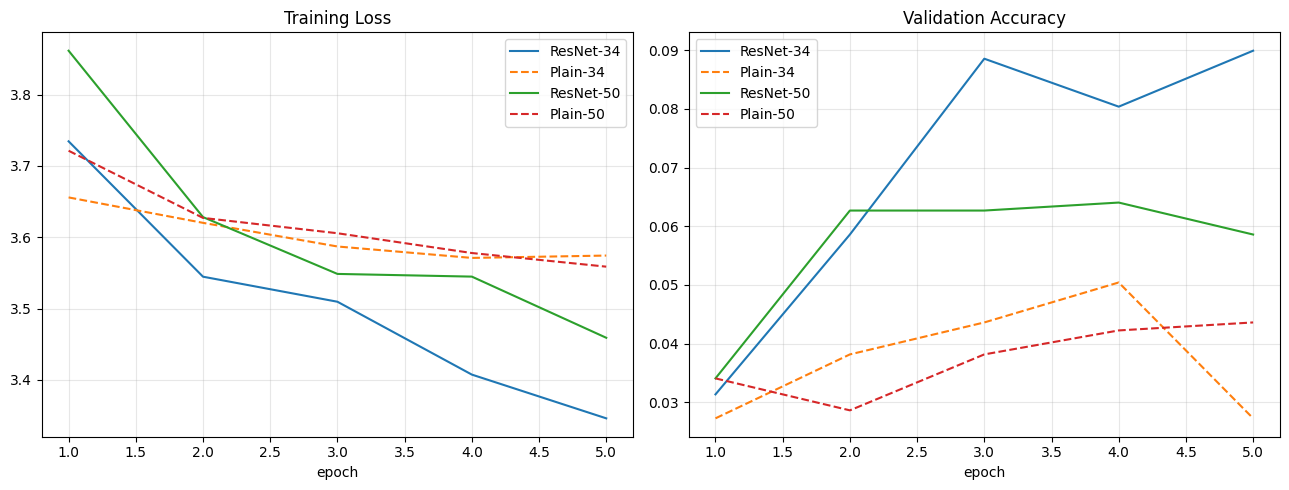

In [30]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
ep = range(1, EPOCHS + 1)
for name, h in results.items():
    style = '-' if 'ResNet' in name else '--'   # ResNet 실선, Plain 점선
    axes[0].plot(ep, h['train_loss'], style, label=name)
    axes[1].plot(ep, h['val_acc'],    style, label=name)
axes[0].set_title('Training Loss'); axes[0].set_xlabel('epoch')
axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].set_title('Validation Accuracy'); axes[1].set_xlabel('epoch')
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 8. 최종 평가 (test)
학습·비교가 모두 끝난 뒤, 보관해 둔 4모델을 **test 셋으로 딱 한 번** 평가한다.
val은 비교/선택에 썼으니, test로 손대지 않은 데이터에서의 최종 성능을 확인한다.

In [31]:
criterion = nn.CrossEntropyLoss()
print(f'{"모델":10s} {"val_acc(최종)":>13s} {"test_acc":>10s}')
print('-' * 36)
for name, model in trained.items():
    model = model.to(device)
    _, test_acc = evaluate(model, test_loader, criterion)
    val_acc = results[name]['val_acc'][-1]
    print(f'{name:10s} {val_acc:>13.4f} {test_acc:>10.4f}')
    model.to('cpu')
    if torch.cuda.is_available(): torch.cuda.empty_cache()

모델           val_acc(최종)   test_acc
------------------------------------
ResNet-34         0.0899     0.0698
Plain-34          0.0272     0.0346
ResNet-50         0.0586     0.0651
Plain-50          0.0436     0.0352


## 9. 추가 시도 기록

기본 루브릭에 더해 스스로 넣은 시도들.

1. **train / val / test 3분할 + 층화(stratified):** HF의 train을 층화 80/20으로
   나눠 검증셋을 별도로 만들고, test는 최종 평가용으로만 사용했다. 학습 중 비교는 val로, 최종 성능은 test로 분리했다.
2. **시드 고정으로 공정한 Ablation:** 매 모델 학습 직전 `set_seed(SEED)`로 초기
   가중치까지 통일 → 성능 차이가 skip 때문인지 초기값 운인지 헷갈리지 않게 했다.
3. **train accuracy 함께 기록:** val만 보지 않고 train/val 격차로 "학습 실패(둘 다 낮음) vs 과적합(train만 높음)"을 구분할 수 있게 했다.
4. **1 epoch 시간 견적(§5):** 본 실험 전에 소요시간을 재서 전체 학습 계획을 세웠다.

## 10. 전체 실행 플로우

In [41]:
import matplotlib as mpl
mpl.rcParams['font.family'] = 'DejaVu Sans'
mpl.rcParams['axes.unicode_minus'] = False

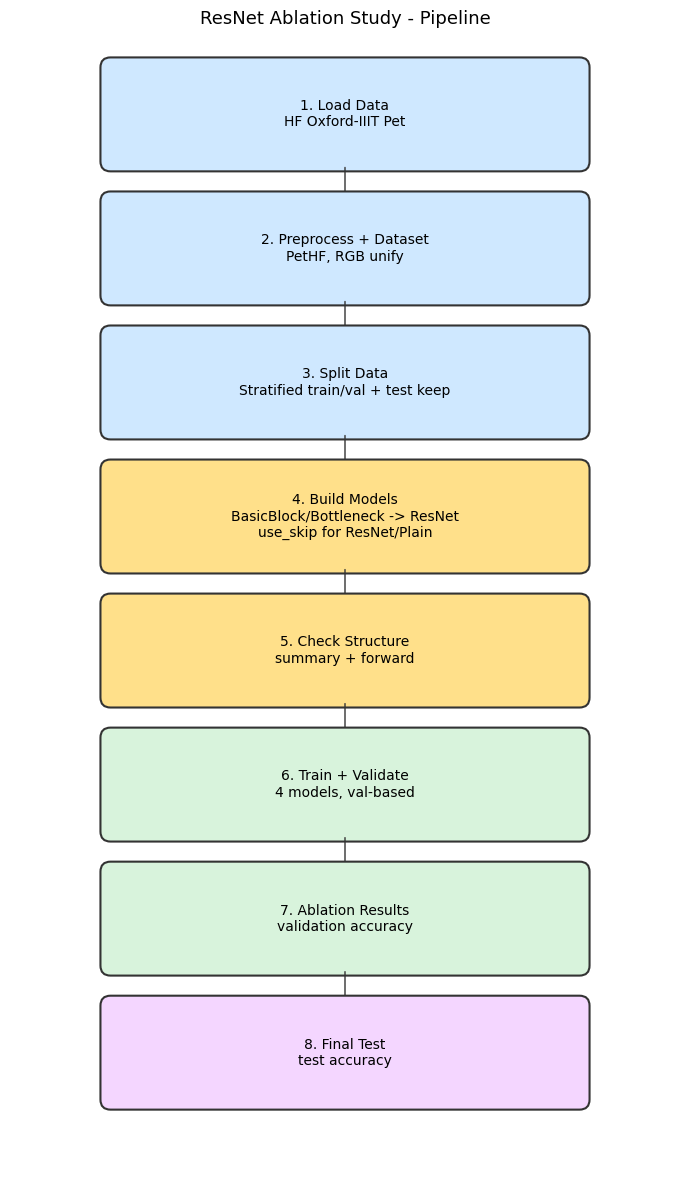

In [42]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

steps = [
    "1. Load Data\nHF Oxford-IIIT Pet",
    "2. Preprocess + Dataset\nPetHF, RGB unify",
    "3. Split Data\nStratified train/val + test keep",
    "4. Build Models\nBasicBlock/Bottleneck -> ResNet\nuse_skip for ResNet/Plain",
    "5. Check Structure\nsummary + forward",
    "6. Train + Validate\n4 models, val-based",
    "7. Ablation Results\nvalidation accuracy",
    "8. Final Test\ntest accuracy",
]

fig, ax = plt.subplots(figsize=(7, 12))
ax.set_xlim(0, 10)
ax.set_ylim(0, len(steps) * 2 + 1)
ax.axis("off")

y = len(steps) * 2
for i, text in enumerate(steps):
    if i <= 2:
        color = "#cfe8ff"
    elif i <= 4:
        color = "#ffe08a"
    elif i <= 6:
        color = "#d8f3dc"
    else:
        color = "#f4d6ff"

    ax.add_patch(FancyBboxPatch(
        (1.5, y - 0.8), 7, 1.4,
        boxstyle="round,pad=0.15",
        facecolor=color, edgecolor="#333", linewidth=1.5
    ))
    ax.text(5, y - 0.1, text, ha="center", va="center", fontsize=10)

    if i < len(steps) - 1:
        ax.add_patch(FancyArrowPatch(
            (5, y - 0.85), (5, y - 1.55),
            arrowstyle="-|>", mutation_scale=18, color="#333"
        ))
    y -= 2

ax.set_title("ResNet Ablation Study - Pipeline", fontsize=13, pad=12)
plt.tight_layout()
plt.show()

## 11. 회고

### 배운 점
- residual connection이 코드상 `out = F(x) + shortcut(x)` **한 줄**이고, 이 한 줄이 깊은 망의 학습 안정성을 좌우한다는 것을 직접 구현으로 이해했다.
- `use_skip` 플래그 하나로 ResNet/Plain을 모두 만드는 설계가 ablation을 얼마나
  깔끔하게 만드는지 체감했다.
- train/val/test를 나누는 이유(val=비교·선택, test=최종 확인)를 실습으로 정리했다.

### 아쉬운 점
- epoch=5로 짧아 수렴을 다 못 봤다.
- 증강을 더 시도해 봐도 좋을 것 같다.

### 느낀 점 / 결과 해석
- (결과표 기준) 같은 깊이·조건에서 ResNet이 Plain보다 았고, 깊이가 깊을수록(50)
  격차는 작아졌다 → residual의 효과가 드러났다.
- val과 test accuracy가 차이가 났다. → 특정 셋에 치우침이 있다고 볼 수 있다.